# Import

In [1]:
import re
import ast
import time
import pandas as pd
from openai import OpenAI
import yaml
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import numpy as np
from bidi.algorithm import get_display

# Configuration

In [2]:
config_path = os.path.join('..', 'config', 'config.yaml')
PARAMS = yaml.safe_load(open(config_path, 'r', encoding='utf-8'))

TYPES = ['no_titles'] 
CSV_PATH_TEMPLATE = os.path.join('..', PARAMS['CSV_PATH'])  # Contains {type} placeholder
RESULTS_PATH = os.path.join('..', PARAMS['RESULTS_PATH'])
GT_PATH = os.path.join('..', PARAMS['GT_PATH'])
client = OpenAI(api_key=PARAMS['OPENAI_API_KEY'])

# Helper function to get CSV path with type formatted
def get_csv_path(type_name):
    return CSV_PATH_TEMPLATE.format(type=type_name)

ALLOWED = {
    "עובדות המקרה",
    "ראיות לעונש",
    "טיעוני הצדדים",
    "תסקיר שירות מבחן",
    "דיון והכרעה",
    "מידע אחר",
}

# Prompts

In [64]:
FEW_SHOT_EXAMPLES= """
### FEW-SHOT EXAMPLES

#### Example — עובדות המקרה (1)
USER:
כותרת: "כללי"
טקסט:
"ביום 12.3.22 הנאשם נסע ברכב שבו הוחזק סם מסוכן במשקל 3 ק״ג."

ASSISTANT:
עובדות המקרה

#### Example — עובדות המקרה (2)
USER:
כותרת: "רקע"
טקסט:
"הורשעו לפי הודאתם בעבירה של יבוא סם מסוכן לפי סעיף 13."

ASSISTANT:
עובדות המקרה

#### Example — גזר דין (3)
USER:
כותרת: "רקע"
טקסט:
"הנאשם, הורשע על יסוד הודאתו, בעובדות כתב האישום מתוקן13."

ASSISTANT:
עובדות המקרה

---
#### Example — ראיות לעונש (1)
USER:
כותרת: "ראיות לעונש"
טקסט:
"התביעה הציגה חוות דעת של מומחה לפסיכולוגיה פלילית."
ASSISTANT:
ראיות לעונש


#### Example — ראיות לעונש (2)
USER:
כותרת: "מסמכים לעונש"
טקסט:
"ההגנה הציגה מכתב המלצה ממעסיקו של הנאשם."

ASSISTANT:
ראיות לעונש

---

#### Example — טיעוני הצדדים (1)
USER:
כותרת: "טיעוני המאשימה"
טקסט:
"המאשימה מבקשת להשית על הנאשם מאסר בפועל בשל חומרת העבירה."

ASSISTANT:
טיעוני הצדדים

#### Example — טיעוני הצדדים (2)
USER:
כותרת: "טיעוני ההגנה"
טקסט:
"הסנגור טען כי הנאשם נגרר על ידי אחרים ולא יזם את המעשה."

ASSISTANT:
טיעוני הצדדים

---

#### Example — תסקיר שירות מבחן (1)
USER:
כותרת: "תסקיר שירות המבחן"
טקסט:
"שירות המבחן מציין כי הנאשם משתף פעולה עם גורמי הטיפול."

ASSISTANT:
תסקיר שירות מבחן

#### Example — תסקיר שירות מבחן (2)
USER:
כותרת: "תסקיר משלים"
טקסט:
"קצינת המבחן מתארת התקדמות יציבה בתהליך השיקום."

ASSISTANT:
תסקיר שירות מבחן

---

#### Example — דיון והכרעה (1)
USER:
כותרת: "דיון"
טקסט:
"מצאתי כי מתחם הענישה ההולם נע בין 10 ל־18 חודשי מאסר."

ASSISTANT:
דיון והכרעה

#### Example — דיון והכרעה (2)
USER:
כותרת: "קביעת המתחם"
טקסט:
"בהתאם לפסיקה, יש לתת משקל רב לשיקולי הרתעה."

ASSISTANT:
דיון והכרעה

---

#### Example — מידע אחר (1)
USER:
כותרת: "זכות ערעור"
טקסט:
"על פסק דין זה ניתן לערער תוך 45 ימים."

ASSISTANT:
מידע אחר

#### Example — מידע אחר (2)
USER:
כותרת: "נספחים"
טקסט:
"מזכירות בית המשפט תמציא העתק גזר דין לשירות המבחן."

ASSISTANT:
מידע אחר

"""


SYSTEM_PROMPT_TEXT = f"""
אתה מומחה לסיווג משפטים ופסקאות מתוך פסקי דין ישראליים.
עליך לסווג כל משפט/פסקה לאחת (ורק אחת) מהקטגוריות הבאות:

1. עובדות המקרה
2. ראיות לעונש
3. טיעוני הצדדים
4. תסקיר שירות מבחן
5. דיון והכרעה
6. מידע אחר

להלן המדריך המלא לסיווג:

────────────────────────────────────────
1. **עובדות המקרה**
תיאור עובדתי של האירוע והנסיבות: מה קרה, כיצד, באילו עבירות הואשם/הודה הנאשם, רקע, מבוא, השתלשלות עניינים, עובדות כתב האישום, וכן פרטים מתוך הסדר טיעון.
**מילות מפתח חזקות:** "כתב האישום", "העובדות", "כללי", "פתח דבר", "עבירה", "רקע", "מבוא", "השתלשלות", "על פי עובדות האישום", "הסדר טיעון", "עובדות כתב האישום".
**הערות:**
- "הסדר טיעון" מסווג כמעט תמיד כאן (אלא אם הכותרת מתמקדת בטענות).
- אם מופיעות טענות ברורות של צדדים → שקול "טיעוני הצדדים".

────────────────────────────────────────
4. **תסקיר שירות מבחן**
כל טקסט המופק ע"י שירות המבחן. כולל תסקיר רגיל, תצהירי נפגעי העבירה, משלים או הערכות שיקום.
**מילות מפתח:** "תסקיר", "תסקירים", "שירות המבחן", "קצינת מבחן", "חוות דעת הממונה", "התרשמות".
**הערה:** כמעט כל אזכור מפורש ל"תסקיר" → שייך לכאן.

────────────────────────────────────────
2. **ראיות לעונש**
כל מידע שמוגש לבית המשפט לצורך קביעת העונש: עבר פלילי, חוות דעת, עדי אופי, מסמכים.
**מילות מפתח:** "ראיות לעונש", "חוות דעת", "מכתבים", "מסמכים", "עדים", "מוצגים".
**הערה:** אם הכותרת עוסקת בראיה עצמה – ולא בטענות – היא משתייכת לכאן.

────────────────────────────────────────
3. **טיעוני הצדדים**
כותרות המציגות את טענות התביעה/הגנה, סיכומים, עמדות ענישה, דברי נאשם.
**מילות מפתח:** "טיעוני המאשימה", "טיעוני ההגנה", "דברי הנאשם", "עותרת", "מבקשת", "טוען", "סיכומים", "הטיעונים לעונש", "תגובה לעונש".
**אינדיקציות חזקות:** הופעת גורמים מדברים — "ב\"כ המאשימה", "הסנגור טען", "המאשימה מבקשת", "הנאשם אומר".


────────────────────────────────────────
5. **דיון והכרעה**
חלק משפטי-שיפוטי: ניתוח הלכתי, קביעת מתחם ענישה, דיון בשיקולים, הפניות לפסיקה, קביעות השופט ומסקנות לגבי העונש.
**מילות מפתח:** "דיון", "הכרעה", "מתחם הענישה", "השיקולים", "מצאתי", "סבורני", "עליי לקבוע", "העונש המתאים", "סוף דבר".
**אינדיקציות חזקות:**
- דיבור בגוף ראשון יחיד של השופט: "מצאתי", "הגעתי למסקנה".
- ניתוח משפטי, הפניות לע"פ/בע"פ, מתחמי ענישה, שיקולי שיקום/הרתעה.
**לא נחשב דיון והכרעה:** תיאור עונש שהוטל *בעבר* או במסגרת עובדות המקרה; או טענות הצדדים.

────────────────────────────────────────
6. **מידע אחר**
כל תוכן טכני/פרוצדורלי שאינו חלק מהותי של פסק הדין.
דוגמאות: "זכות ערעור", מידע מזהה (שמות נאשמים/בא כוח), כותרות ריקות, מידע מנהלי.
**להשתמש בזה רק אם אין התאמה ממשית לאף קטגוריה.**

────────────────────────────────────────
## כללי רצף והיררכיה בין קטגוריות (חובה!)

פסקי דין בישראל כמעט תמיד בנויים בסדר הבא:

1. מידע אחר (אם קיים)  
2. עובדות המקרה  
3-5. ראיות לעונש, טיעוני הצדדים, תסקיר שירות מבחן (בכל סדר)
6. דיון והכרעה  

**אסור לחזור אחורה בסדר!**  
לדוגמה:
אם הפסקה הקודמת היא "עובדות" → הסיווג הנוכחי **לא יכול** להיות "דיון והכרעה".  
אם הפסקה הקודמת היא "דיון והכרעה" → גם הנוכחית חייבת להיות "דיון והכרעה".  

החריג היחיד: "מידע אחר" יכול להופיע גם בסוף (למשל: זכות ערעור).

────────────────────────────────────────

## דוגמאות של סיווג 

{FEW_SHOT_EXAMPLES}

────────────────────────────────────────

### פורמט פלט:
החזר **אך ורק** אחת מהמחרוזות הבאות:
"עובדות המקרה" | "ראיות לעונש" | "טיעוני הצדדים" | "תסקיר שירות מבחן" | "דיון והכרעה" | "מידע אחר"

אסור להחזיר כל הסבר, נימוק או טקסט נוסף.
"""

# Functions

In [65]:
def ask_gpt_single(title: str, last_class) -> str:
    """Query the model for a single title → single category (string)."""
    # Per-item user prompt, very strict
    user_prompt = f"""
        הסיווג של הטקסט הקודמת הוא:
        "{last_class}"

        טקסט :
        "{title}"
        
        עליך לבחור קטגוריה אחת בלבד מתוך הרשימה, לפי כללי ההיררכיה הבאה:

        1. מידע אחר  
        2. עובדות המקרה  
        3. ראיות לעונש  
        4. טיעוני הצדדים  
        5. תסקיר שירות מבחן  
        6. דיון והכרעה  

        כללים מחייבים:
        - אסור לחזור אחורה בהיררכיה.
        - אם הסיווג הקודם גבוה יותר (למשל דיון והכרעה), גם הנוכחי חייב להישאר באותה רמה.
        - "עובדות המקרה" חייב להופיע לפני כל היתר (מלבד מידע אחר).
        - סיווג דיון והכרעה לא יכול להופיע אחרי סיווג של עובדות המקרה.
        - "מידע אחר" יכול להופיע גם בסוף (למשל זכות ערעור).
        - תמיד תחשוב קודם על הסיווג הקודם, בדרך כלל הסיווג הבא אותו הדבר אלא אם הטקסט מראה אחרת.

        החזר את שם הסיווג בלבד — ללא כל הסבר.
        """
    
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_TEXT},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )
    out = (resp.choices[0].message.content or "").strip()

    # Normalize minor quotes/spaces
    out = out.replace('"', '').replace("'", "").strip()

    # If model returned extra text like "Mapped: XXX"
    # try to pull a known category substring
    if out not in ALLOWED:
        for cat in ALLOWED:
            if cat in out:
                out = cat
                break

    # Final guardrail
    if out not in ALLOWED:
        out = "מידע אחר"

    return out


def ask_gpt_many(text,last_class, last_text, last_last_class, last_last_text, next_text) -> str:
    """Query the model for a single title → single category (string)."""
    # Per-item user prompt, very strict
    user_prompt = f"""
    להלן מידע על הפסקאות הקודמות לצורך שמירה על רצף נכון:

    הסיווג הקודם: "{last_class}"
    הטקסט הקודם:
    "{last_text}"

    טקסט לסיווג כעת:
    "{text}"

    עליך לבחור קטגוריה אחת בלבד מתוך הרשימה, לפי כללי ההיררכיה הבאה:

    1. מידע אחר  
    2. עובדות המקרה  
    3. ראיות לעונש  
    4. טיעוני הצדדים  
    5. תסקיר שירות מבחן  
    6. דיון והכרעה  

    כללים מחייבים:
    - אסור לחזור אחורה בהיררכיה.
    - אם הסיווג הקודם גבוה יותר (למשל דיון והכרעה), גם הנוכחי חייב להישאר באותה רמה.
    - "עובדות המקרה" חייב להופיע לפני כל היתר (מלבד מידע אחר).
    - אתה לא יכול לסווג "דיון והכרעה""  אם הופיע בסיווג הקודם עובדות המקרה.
    - "מידע אחר" יכול להופיע גם בסוף (למשל זכות ערעור).

    החזר את שם הסיווג בלבד — ללא כל הסבר.
    """

    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_TEXT},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )
    out = (resp.choices[0].message.content or "").strip()

    # Normalize minor quotes/spaces
    out = out.replace('"', '').replace("'", "").strip()

    # If model returned extra text like "Mapped: XXX"
    # try to pull a known category substring
    if out not in ALLOWED:
        for cat in ALLOWED:
            if cat in out:
                out = cat
                break

    # Final guardrail
    if out not in ALLOWED:
        out = "מידע אחר"

    return out


def map_titles_row_by_row(df: pd.DataFrame, text_column: str, SYSTEM_PROMPT, signal) -> pd.DataFrame:
    mapped = []
    df_len = len(df)
    i = 0
    last_class = ""
    last_text = ""
    last_last_class = ""
    last_last_text = ""
    next_text = ""

    texts = df[text_column].astype(str).tolist()
    
    for idx, text in enumerate(texts):
        # Get next_text (the text after current one, if exists)
        next_text = texts[idx + 1] if idx + 1 < len(texts) else ""

        # retry logic (handles transient API issues)
        attempts = 0
        while True:
            attempts += 1
            try:
                # if last_class == "דיון והכרעה":
                #     # the rest of the categories will be דיון והכרעה
                #     category = "דיון והכרעה"
                if signal == 0:
                    category = ask_gpt_single(text, last_class)
                else:
                    category = ask_gpt_many(text,last_class, last_text, last_last_class, last_last_text, next_text)
                
                mapped.append(category)
                i += 1
                print(f"✅ ({i}/{df_len}) Mapped into '{category}'")
                
                # Update tracking variables for next iteration
                last_last_class = last_class
                last_last_text = last_text
                last_class = category
                last_text = text
                break
            except Exception as e:
                if attempts >= 3:
                    print(f"❌ Failed on '{text[:50]}...' → defaulting to 'מידע אחר' ({e})")
                    mapped.append("מידע אחר")
                    
                    # Update tracking variables even on failure
                    last_last_class = last_class
                    last_last_text = last_text
                    last_class = "מידע אחר"
                    last_text = text
                    break
                time.sleep(0.8 * attempts)  # simple backoff

    df = df.copy()
    df["mapped_category"] = mapped
    return df

# Run

In [56]:
for type in TYPES:
    Folder_path = get_csv_path(type)
    j =0
    for file in os.listdir(Folder_path):
        if file != "SH-24-01-26596-264.csv":
            continue
        for i in range(0,2):
            df = pd.read_csv(os.path.join(Folder_path, file))
            text_column = "text"
            if i == 0:
                case = "one_last_class"
            else:
                case = "last_text_and_classes"
            df_results = map_titles_row_by_row(df, text_column ,SYSTEM_PROMPT_TEXT,i)
                
            out_dir = os.path.join(RESULTS_PATH, type, case)

            os.makedirs(out_dir, exist_ok=True)
            out_path = os.path.join(out_dir, f"{file}")
            df_results.to_csv(out_path, index=False)

            j += 1
            print(f"✅ Saved: {out_path}")
            print(f"Processed {j} files from {len(os.listdir(Folder_path))} in {type} type.")

✅ (1/116) Mapped into 'מידע אחר'
✅ (2/116) Mapped into 'מידע אחר'
✅ (2/116) Mapped into 'מידע אחר'
✅ (3/116) Mapped into 'מידע אחר'
✅ (3/116) Mapped into 'מידע אחר'
✅ (4/116) Mapped into 'מידע אחר'
✅ (4/116) Mapped into 'מידע אחר'
✅ (5/116) Mapped into 'עובדות המקרה'
✅ (5/116) Mapped into 'עובדות המקרה'
✅ (6/116) Mapped into 'עובדות המקרה'
✅ (6/116) Mapped into 'עובדות המקרה'
✅ (7/116) Mapped into 'עובדות המקרה'
✅ (7/116) Mapped into 'עובדות המקרה'
✅ (8/116) Mapped into 'עובדות המקרה'
✅ (8/116) Mapped into 'עובדות המקרה'
✅ (9/116) Mapped into 'עובדות המקרה'
✅ (9/116) Mapped into 'עובדות המקרה'
✅ (10/116) Mapped into 'עובדות המקרה'
✅ (10/116) Mapped into 'עובדות המקרה'
✅ (11/116) Mapped into 'עובדות המקרה'
✅ (11/116) Mapped into 'עובדות המקרה'
✅ (12/116) Mapped into 'עובדות המקרה'
✅ (12/116) Mapped into 'עובדות המקרה'
✅ (13/116) Mapped into 'עובדות המקרה'
✅ (13/116) Mapped into 'עובדות המקרה'
✅ (14/116) Mapped into 'עובדות המקרה'
✅ (14/116) Mapped into 'עובדות המקרה'
✅ (15/116) Mapped i

# All results to csv

In [ ]:
for TYPE in TYPES:
    gt_df = pd.read_csv(os.path.join(GT_PATH, 'all_combined_sorted.csv'))
    
    path = os.path.join(RESULTS_PATH, TYPE, "one_last_class")
    one_last_class = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            one_last_class = pd.concat([one_last_class, df], ignore_index=True)
    path = os.path.join(RESULTS_PATH, TYPE, "last_text_and_classes")
    last_text_and_classes = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            last_text_and_classes = pd.concat([last_text_and_classes, df], ignore_index=True)

    one_last_class = one_last_class["mapped_category"].tolist()
    last_text_and_classes = last_text_and_classes["mapped_category"].tolist()

    # add results to gt_df
    gt_df['one_last_class'] = one_last_class
    gt_df['last_text_and_classes'] = last_text_and_classes
    # save gt_df
    gt_df.to_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'), index=False)

# Plots

## confusion matrix


==================== Evaluating TYPE: no_titles ====================

====== Evaluating: one_last_class ======


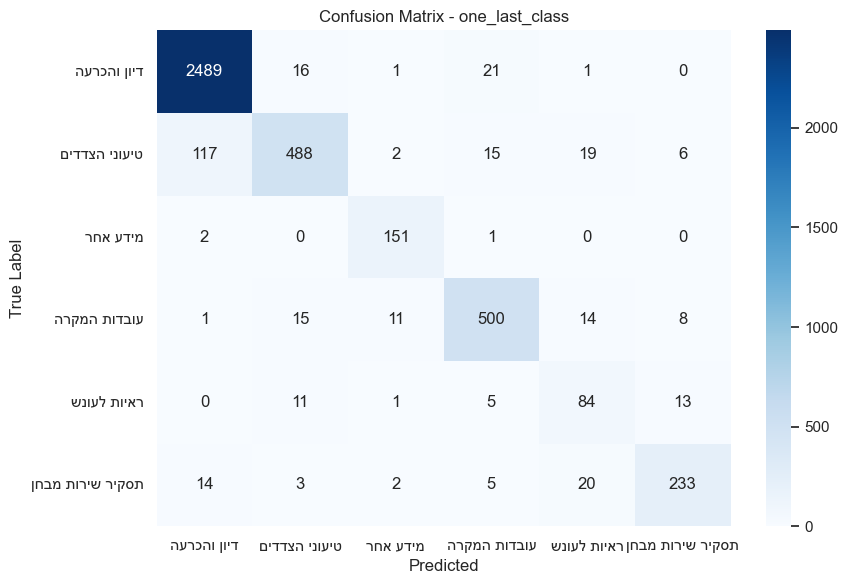


====== Evaluating: last_text_and_classes ======


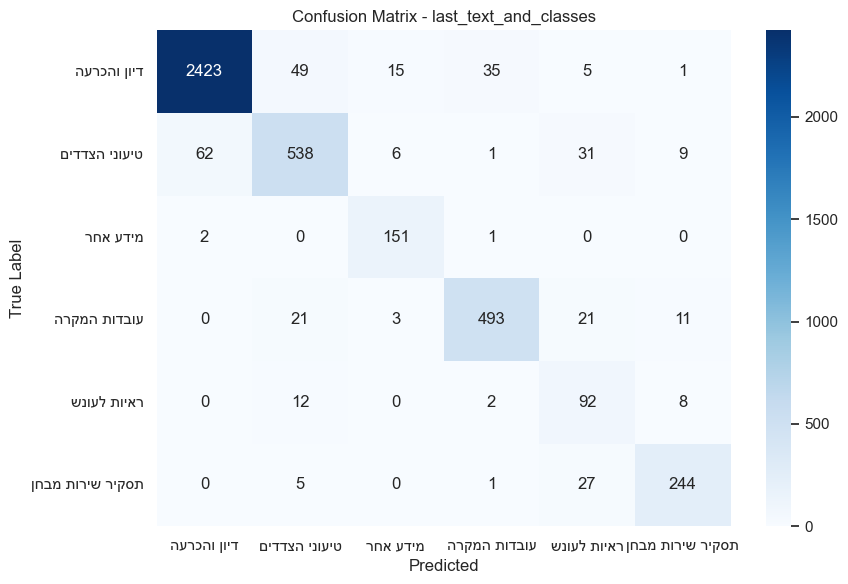

In [20]:
for TYPE in TYPES:
    # -----------------------------
    #  LOAD DATA
    # -----------------------------
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    print(f"\n==================== Evaluating TYPE: {TYPE} ====================")
    # Columns to evaluate
    prediction_columns = ['one_last_class','last_text_and_classes']
    ground_truth_column = 'label'

    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')

    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)

    unique_labels = sorted(results_df[ground_truth_column].unique())
    unique_labels_display = [get_display(label) for label in unique_labels]

    # Save all per-label rows across all models
    all_per_label_rows = []

    # Global metrics storage
    global_metric_rows = []

    sns.set_theme(style="whitegrid")

    # -----------------------------
    # LOOP OVER MODELS
    # -----------------------------
    for col in prediction_columns:
        print(f"\n====== Evaluating: {col} ======")

        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]

        # Accuracy
        acc = accuracy_score(y_true, y_pred)

        # Micro / Macro / Weighted
        micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        # Save global metrics
        global_metric_rows.append({
            'Input_Type': col,
            'Overall_Accuracy': acc,
            'Micro-F1': micro_f1,
            'Macro-F1': macro_f1,
            'Weighted-F1': weighted_f1
        })

        # -----------------------------
        #  PER-LABEL METRICS
        # -----------------------------
        per_label = []

        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            support = (y_true == label).sum()

            per_label.append({
                'Input_Type': col,
                'Class': label,
                'Class_Display': get_display(label),
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1,
                'Support': support
            })

        # Convert to DataFrame
        per_label_df = pd.DataFrame(per_label)

        # Add to global per-class storage
        all_per_label_rows.append(per_label_df)

        
        # -----------------------------
        # VISUALIZATIONS
        # -----------------------------

        # 1. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        plt.figure(figsize=(9, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                    xticklabels=unique_labels_display, yticklabels=unique_labels_display)
        plt.title(f"Confusion Matrix - {col}")
        plt.xlabel("Predicted")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()




## Count of Each Label

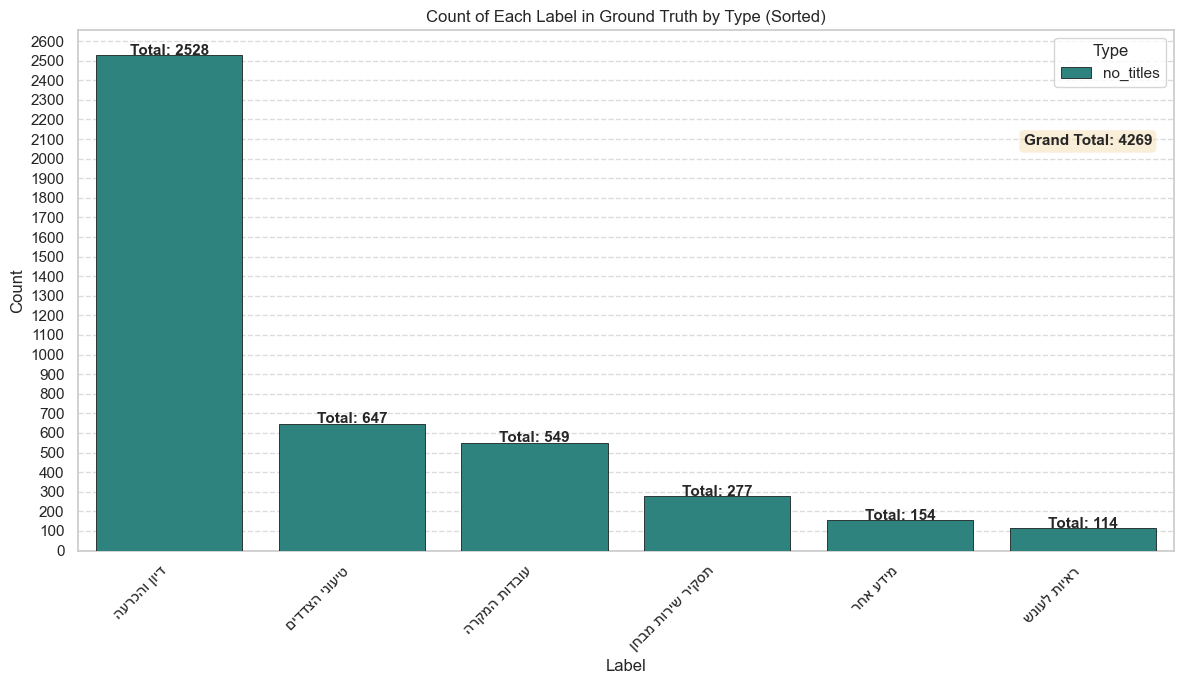

In [ ]:
gt_dfs = []
for TYPE in TYPES:
    gt_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    gt_df['type'] = TYPE
    gt_dfs.append(gt_df)
combined_gt_df = pd.concat(gt_dfs, ignore_index=True)

# Drop rows with NaN labels
combined_gt_df = combined_gt_df.dropna(subset=['label'])

# Calculate counts and sort by total (descending - largest on left)
label_counts = combined_gt_df.groupby('label').size().reset_index(name='total')
label_order = label_counts.sort_values('total', ascending=False)['label'].tolist()

# Create display labels (RTL fix) - convert to string first to handle any remaining issues
combined_gt_df['label_display'] = combined_gt_df['label'].astype(str).apply(get_display)
label_order_display = [get_display(str(l)) for l in label_order]

# Calculate totals for annotation
totals_per_label = combined_gt_df.groupby('label_display').size().to_dict()

grand_total = len(combined_gt_df)

plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=combined_gt_df,
    x='label_display',
    hue='type',
    order=label_order_display,
    palette='viridis',
    edgecolor='black',           # make sure bars are clearly above the grid
    linewidth=0.5,
    zorder=3                     # draw bars above grid lines
)

# Add horizontal grid lines at y=100 intervals (behind bars)
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(plt.MultipleLocator(100))
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Add total annotations on top of bars
for label_display in label_order_display:
    total = totals_per_label.get(label_display, 0)
    x_pos = label_order_display.index(label_display)
    # Get the max height for this label
    max_height = 0
    for p in ax.patches:
        if abs(p.get_x() + p.get_width()/2 - x_pos) < 0.5:
            max_height = max(max_height, p.get_height())
    ax.annotate(
        f'Total: {total}',
        (x_pos, max_height + 3),
        ha='center',
        fontsize=11,
        fontweight='bold',
        zorder=4
    )

plt.title('Count of Each Label in Ground Truth by Type (Sorted)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

grand_total = len(combined_gt_df)
legend = plt.legend(title='Type', loc='upper right')
ax.annotate(f'Grand Total: {grand_total}', xy=(0.98, 0.8), xycoords='axes fraction',
             ha='right', va='top', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


plt.tight_layout()
plt.show()

## Per Label Calculation

NO_TITLES


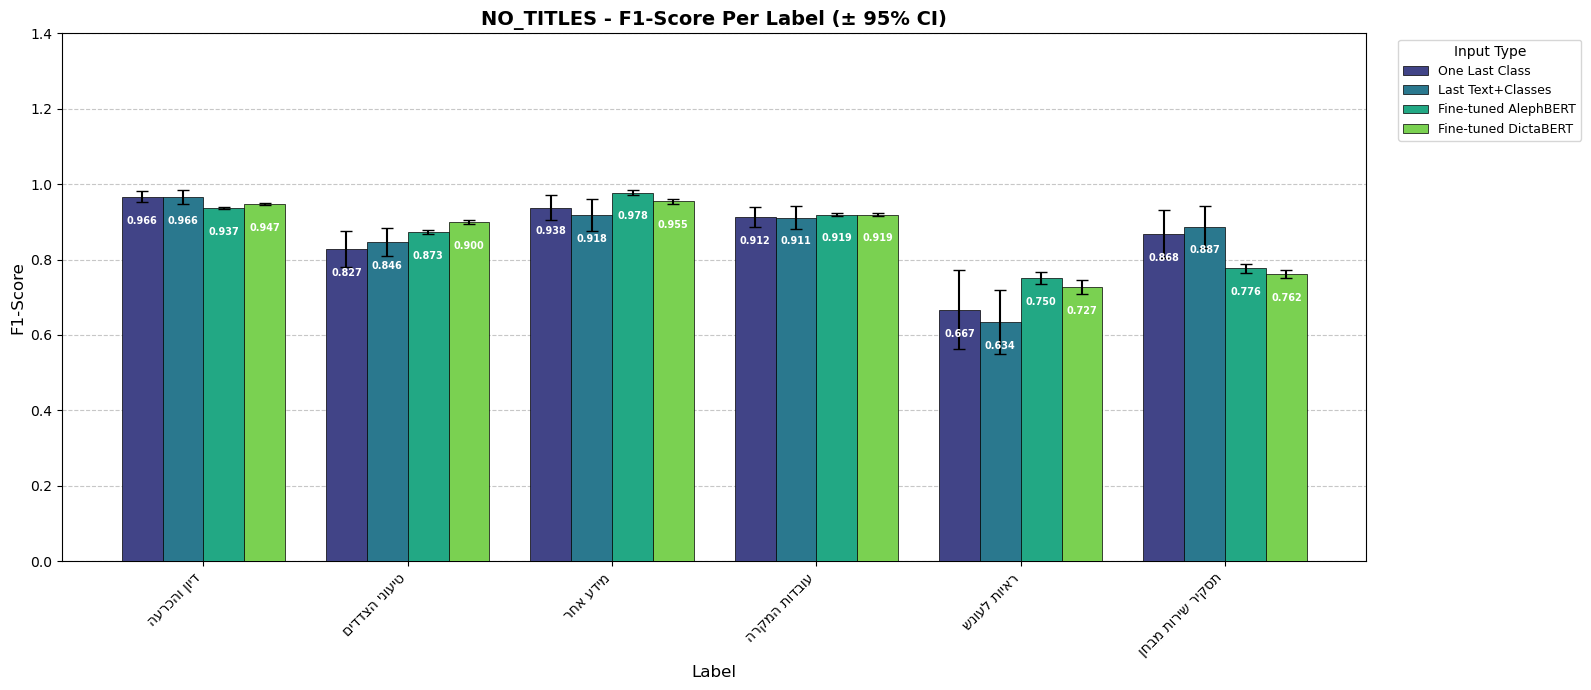

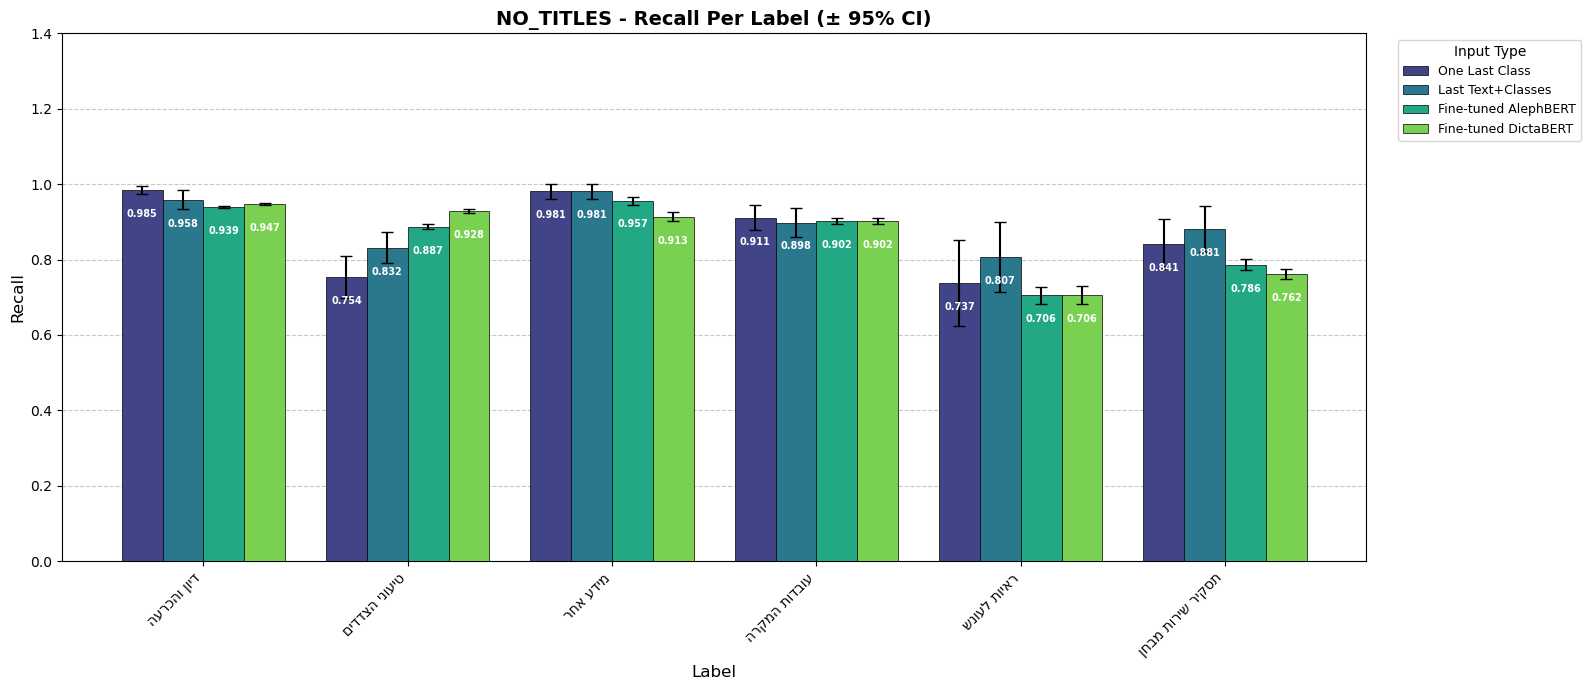

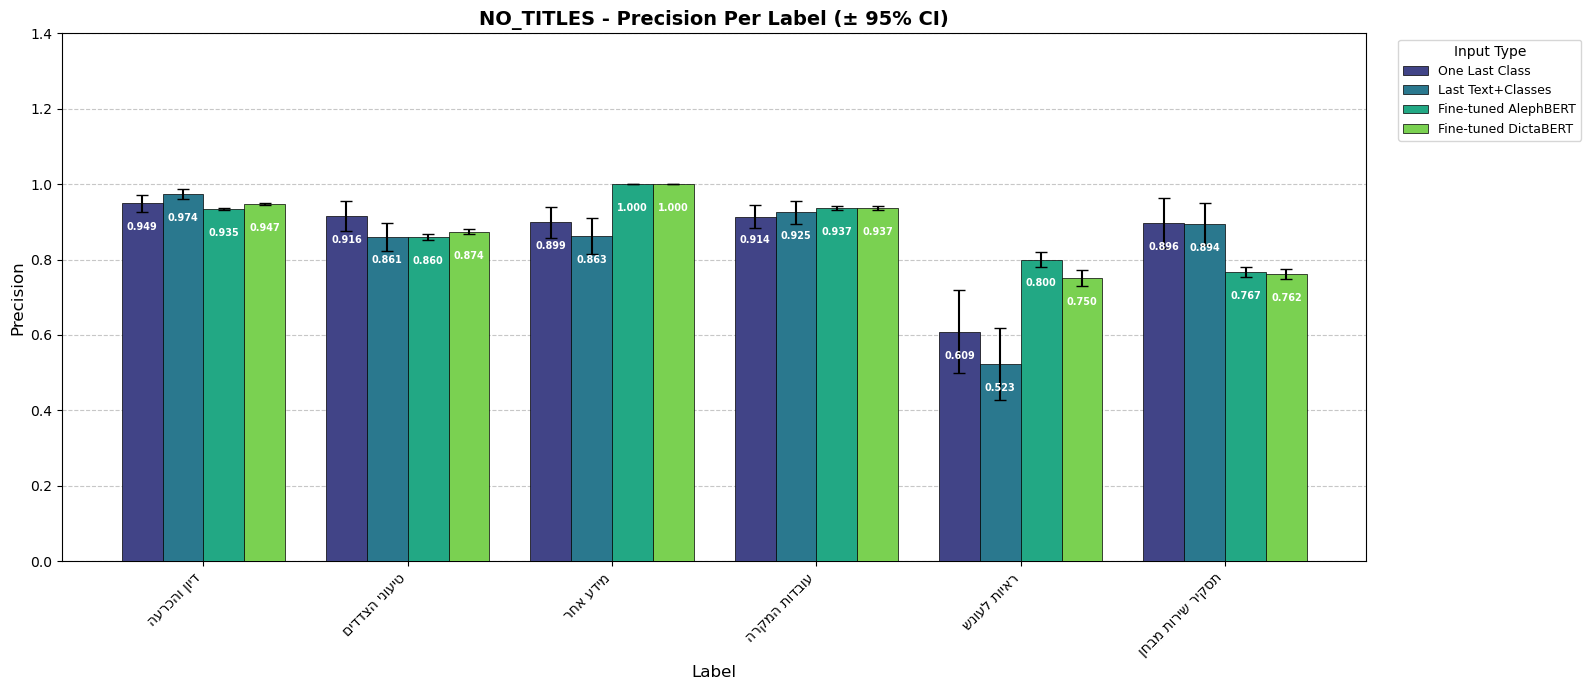

In [3]:
all_metrics = []
all_file_metrics = []  # Per-file metrics for error bars

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

# Load fine-tuning results
fine_tuning_results = pd.read_csv(
    r'C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\fine_tuning\test_predictions.csv'
)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['one_last_class', 'last_text_and_classes']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    # Get file list for per-file metrics (use one_last_class folder)
    path = os.path.join(RESULTS_PATH, TYPE, "one_last_class")
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    # Mapping for column names to display names and folder names
    col_to_input_name = {
        'one_last_class': 'One Last Class',
        'last_text_and_classes': 'Last Text+Classes'
    }
    col_to_folder = {
        'one_last_class': 'one_last_class',
        'last_text_and_classes': 'last_text_and_classes'
    }
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        input_name = col_to_input_name[col]
        
        # Overall metrics per label
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            
            all_metrics.append({
                'Type': TYPE,
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': input_name,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1
            })
        
        # Per-file metrics for error bars
        case_folder = col_to_folder[col]
        start_idx = 0
        
        for file in files:
            file_path = os.path.join(RESULTS_PATH, TYPE, case_folder, file)
            if os.path.exists(file_path):
                file_df = pd.read_csv(file_path)
                file_len = len(file_df)
                if file_len > 0:
                    file_y_true = y_true.iloc[start_idx:start_idx + file_len]
                    file_y_pred = y_pred.iloc[start_idx:start_idx + file_len]
                    
                    for label in unique_labels:
                        if (file_y_true == label).sum() > 0:  # Only if label exists in file
                            file_precision = precision_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            file_recall = recall_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            file_f1 = f1_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            
                            all_file_metrics.append({
                                'Type': TYPE,
                                'File': file,
                                'Label': label,
                                'Label_Display': get_display(label),
                                'Input_Type': input_name,
                                'Precision': file_precision,
                                'Recall': file_recall,
                                'F1-Score': file_f1
                            })
                    
                start_idx += file_len

# ===== Add fine-tuning results to same dataset =====
ft_df = fine_tuning_results.dropna(subset=['label']).copy()
ft_df['label'] = ft_df['label'].astype(str)
ft_df['Label_Display'] = ft_df['label'].apply(get_display)

model_cols = ['alephbert_prediction', 'dicta_prediction']
model_name_map = {
    'alephbert_prediction': 'Fine-tuned AlephBERT',
    'dicta_prediction': 'Fine-tuned DictaBERT'
}

for col in model_cols:
    y_true = ft_df['label'].astype(str)
    y_pred = ft_df[col].astype(str)
    unique_labels_ft = sorted(y_true.unique())
    
    for label in unique_labels_ft:
        label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        
        # Add to the same TYPE dataset (no_titles) so they appear in same plot
        all_metrics.append({
            'Type': 'no_titles',  # Same TYPE as the main dataset
            'Label': label,
            'Label_Display': get_display(label),
            'Input_Type': model_name_map[col],
            'Precision': label_precision,
            'Recall': label_recall,
            'F1-Score': label_f1
        })
# =======================================

metrics_df = pd.DataFrame(all_metrics)
file_metrics_df = pd.DataFrame(all_file_metrics)

# Calculate 95% CI from per-file metrics for each type: CI = Z * (std / sqrt(n))
ci_df = file_metrics_df.groupby(['Type', 'Label_Display', 'Input_Type']).agg({
    'Precision': ['std', 'count'],
    'Recall': ['std', 'count'],
    'F1-Score': ['std', 'count']
}).reset_index()
ci_df.columns = ['Type', 'Label_Display', 'Input_Type', 
                 'Precision_std', 'Precision_n', 
                 'Recall_std', 'Recall_n', 
                 'F1-Score_std', 'F1-Score_n']
ci_df = ci_df.fillna(0)
ci_df['Precision_ci'] = Z_95 * ci_df['Precision_std'] / np.sqrt(ci_df['Precision_n'].replace(0, 1))
ci_df['Recall_ci'] = Z_95 * ci_df['Recall_std'] / np.sqrt(ci_df['Recall_n'].replace(0, 1))
ci_df['F1-Score_ci'] = Z_95 * ci_df['F1-Score_std'] / np.sqrt(ci_df['F1-Score_n'].replace(0, 1))

# ===== Per-verdict CI for fine-tuning models (no bootstrap) =====
ft_file_metrics = []  # Per-verdict metrics for CI calculation

for col in model_cols:
    model_name = model_name_map[col]
    labels_ft = sorted(ft_df['label'].unique())
    
    # Calculate metrics per verdict (file)
    for verdict in ft_df['verdict'].unique():
        verdict_df = ft_df[ft_df['verdict'] == verdict]
        if len(verdict_df) == 0:
            continue
            
        y_true_v = verdict_df['label'].astype(str)
        y_pred_v = verdict_df[col].astype(str)
        
        for label in labels_ft:
            if (y_true_v == label).sum() > 0:
                ft_precision = precision_score(y_true_v, y_pred_v, labels=[label],
                                               average='micro', zero_division=0)
                ft_recall = recall_score(y_true_v, y_pred_v, labels=[label],
                                         average='micro', zero_division=0)
                ft_f1 = f1_score(y_true_v, y_pred_v, labels=[label],
                                 average='micro', zero_division=0)

                ft_file_metrics.append({
                    'Type': 'no_titles',
                    'File': verdict,
                    'Label_Display': get_display(label),
                    'Input_Type': model_name,
                    'Precision': ft_precision,
                    'Recall': ft_recall,
                    'F1-Score': ft_f1
                })

# Convert to DataFrame
ft_file_metrics_df = pd.DataFrame(ft_file_metrics)

# Compute 95% CI for fine-tuned models
ft_ci_df = ft_file_metrics_df.groupby(['Type', 'Label_Display', 'Input_Type']).agg({
    'Precision': ['std', 'count'],
    'Recall': ['std', 'count'],
    'F1-Score': ['std', 'count']
}).reset_index()
ft_ci_df.columns = ['Type', 'Label_Display', 'Input_Type',
                    'Precision_std', 'Precision_n',
                    'Recall_std', 'Recall_n',
                    'F1-Score_std', 'F1-Score_n']
ft_ci_df = ft_ci_df.fillna(0)
ft_ci_df['Precision_ci'] = Z_95 * ft_ci_df['Precision_std'] / np.sqrt(ft_ci_df['Precision_n'].replace(0, 1))
ft_ci_df['Recall_ci'] = Z_95 * ft_ci_df['Recall_std'] / np.sqrt(ft_ci_df['Recall_n'].replace(0, 1))
ft_ci_df['F1-Score_ci'] = Z_95 * ft_ci_df['F1-Score_std'] / np.sqrt(ft_ci_df['F1-Score_n'].replace(0, 1))

# Add these CI rows to the main ci_df
ci_df = pd.concat([ci_df, ft_ci_df], ignore_index=True)

# =====================
# Per-Label Plots for each TYPE (now includes fine-tuning as extra bars)
# =====================
metrics_to_plot = [('F1-Score', 'F1-Score'), ('Recall', 'Recall'), ('Precision', 'Precision')]
input_order = ['One Last Class', 'Last Text+Classes', 'Fine-tuned AlephBERT', 'Fine-tuned DictaBERT']

for TYPE in TYPES:
    print("=" * 50)
    print(f"{TYPE.upper()}")
    print("=" * 50)
    
    type_df = metrics_df[metrics_df['Type'] == TYPE]
    type_ci_df = ci_df[ci_df['Type'] == TYPE]
    
    # Get unique labels for this type
    labels = type_df['Label_Display'].unique().tolist()
    
    # Determine which input types are available for this TYPE
    available_inputs = type_df['Input_Type'].unique().tolist()
    type_input_order = [inp for inp in input_order if inp in available_inputs]
    
    for metric_col, metric_name in metrics_to_plot:
        fig, ax = plt.subplots(figsize=(16, 7))
        
        x = np.arange(len(labels))
        width = 0.8 / len(type_input_order)  # Adjust width based on number of input types
        colors = sns.color_palette('viridis', len(type_input_order))
        
        # Set grid behind bars
        ax.set_axisbelow(True)
        ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
        
        for i, input_type in enumerate(type_input_order):
            means = []
            cis = []
            for label in labels:
                row = type_df[(type_df['Label_Display'] == label) & (type_df['Input_Type'] == input_type)]
                ci_row = type_ci_df[(type_ci_df['Label_Display'] == label) & (type_ci_df['Input_Type'] == input_type)]
                mean_val = row[metric_col].values[0] if len(row) > 0 else 0
                ci_val = ci_row[f'{metric_col}_ci'].values[0] if len(ci_row) > 0 else 0
                means.append(mean_val)
                # Clip CI so error bars don't exceed [0, 1]
                cis.append(clip_ci(mean_val, ci_val))
            
            bars = ax.bar(x + i * width, means, width, label=input_type, color=colors[i],
                          yerr=cis, capsize=4, error_kw={'linewidth': 1.5},
                          edgecolor='black', linewidth=0.5, zorder=3)
            
            # Add value labels
            for j, (bar, mean_val) in enumerate(zip(bars, means)):
                if mean_val > 0.15:
                    ax.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val - 0.05),
                                ha='center', va='top', fontsize=7, fontweight='bold', color='white', zorder=4)
                else:
                    ax.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val + cis[j] + 0.02),
                                ha='center', va='bottom', fontsize=7, fontweight='bold', color='black', zorder=4)
        
        ax.set_xlabel('Label', fontsize=12)
        ax.set_ylabel(metric_name, fontsize=12)
        ax.set_title(f'{TYPE.upper()} - {metric_name} Per Label (± 95% CI)', fontsize=14, fontweight='bold')
        ax.set_xticks(x + width * (len(type_input_order) - 1) / 2)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_ylim(0, 1.4)
        ax.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
        plt.tight_layout()
        plt.show()

## Macro Calculation

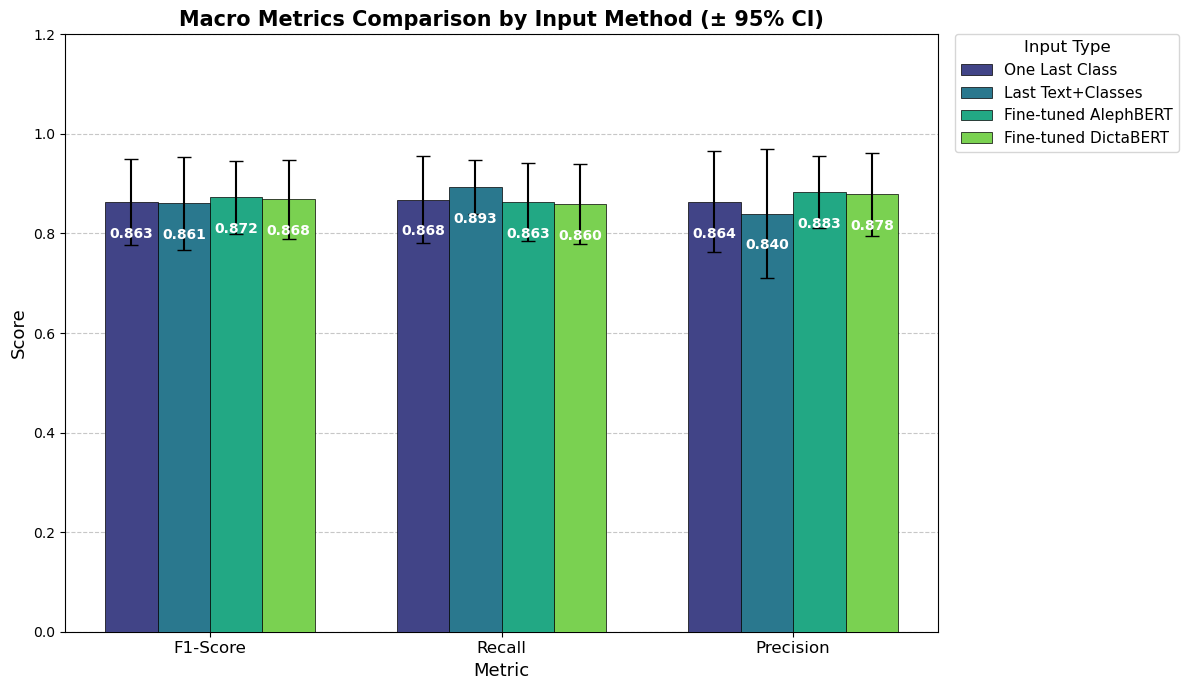

In [4]:
all_metrics = []

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

fine_tuning_results = pd.read_csv(
    r'C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\fine_tuning\test_predictions.csv'
)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH, TYPE, 'all_results.csv'))
    prediction_columns = ['one_last_class', 'last_text_and_classes']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            
            input_name = {'one_last_class': 'One Last Class',
                          'last_text_and_classes': 'Last Text+Classes'}[col]
            
            all_metrics.append({
                'Type': TYPE.capitalize(),
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': input_name,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1
            })

metrics_df = pd.DataFrame(all_metrics)

# ===== Add fine-tuning results as extra "input types" =====
ft_df = fine_tuning_results.dropna(subset=['label']).copy()
ft_df['label'] = ft_df['label'].astype(str)
ft_df['Label_Display'] = ft_df['label'].apply(get_display)

model_cols = ['alephbert_prediction', 'dicta_prediction']
model_name_map = {
    'alephbert_prediction': 'Fine-tuned AlephBERT',
    'dicta_prediction': 'Fine-tuned DictaBERT'
}

for col in model_cols:
    y_true = ft_df['label'].astype(str)
    y_pred = ft_df[col].astype(str)
    unique_labels_ft = sorted(y_true.unique())
    
    for label in unique_labels_ft:
        label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        
        metrics_df = pd.concat([
            metrics_df,
            pd.DataFrame([{
                'Type': 'Fine-tuning',
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': model_name_map[col],
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1
            }])
        ], ignore_index=True)
# ==========================================================

# Calculate overall metrics per Type and Input_Type (mean, std, count for 95% CI)
overall_metrics = metrics_df.groupby(['Type', 'Input_Type']).agg({
    'Precision': ['mean', 'std', 'count'],
    'Recall': ['mean', 'std', 'count'],
    'F1-Score': ['mean', 'std', 'count']
}).reset_index()
overall_metrics.columns = ['Type', 'Input_Type', 
                           'Precision_mean', 'Precision_std', 'Precision_n',
                           'Recall_mean', 'Recall_std', 'Recall_n', 
                           'F1-Score_mean', 'F1-Score_std', 'F1-Score_n']

overall_metrics = overall_metrics.fillna(0)

# Calculate 95% CI
overall_metrics['Precision_ci'] = Z_95 * overall_metrics['Precision_std'] / np.sqrt(overall_metrics['Precision_n'].replace(0, 1))
overall_metrics['Recall_ci'] = Z_95 * overall_metrics['Recall_std'] / np.sqrt(overall_metrics['Recall_n'].replace(0, 1))
overall_metrics['F1-Score_ci'] = Z_95 * overall_metrics['F1-Score_std'] / np.sqrt(overall_metrics['F1-Score_n'].replace(0, 1))

# Single Plot: all metrics on same axes
input_order = ['One Last Class', 'Last Text+Classes',
               'Fine-tuned AlephBERT', 'Fine-tuned DictaBERT']
metric_names = ['F1-Score', 'Recall', 'Precision']

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(metric_names))
width = 0.18
colors = sns.color_palette('viridis', len(input_order))

# Set grid to be behind bars
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

for i, input_type in enumerate(input_order):
    means = []
    cis = []
    row = overall_metrics[overall_metrics['Input_Type'] == input_type]
    for metric in metric_names:
        mean_val = row[f'{metric}_mean'].mean() if len(row) > 0 else 0
        ci_val = row[f'{metric}_ci'].mean() if len(row) > 0 else 0
        means.append(mean_val)
        # Clip CI so error bars don't exceed [0, 1]
        cis.append(clip_ci(mean_val, ci_val))
    
    bars = ax.bar(x + i * width, means, width, label=input_type, color=colors[i],
                   yerr=cis, capsize=5, error_kw={'linewidth': 1.5},
                   edgecolor='black', linewidth=0.5, zorder=3)
    
    for j, (bar, mean_val) in enumerate(zip(bars, means)):
        if mean_val > 0.15:
            ax.annotate(f'{mean_val:.3f}',
                         (bar.get_x() + bar.get_width()/2., mean_val - 0.05),
                         ha='center', va='top', fontsize=10,
                         fontweight='bold', color='white', zorder=4)
        else:
            ax.annotate(f'{mean_val:.3f}',
                         (bar.get_x() + bar.get_width()/2., mean_val + cis[j] + 0.02),
                         ha='center', va='bottom', fontsize=10,
                         fontweight='bold', color='black', zorder=4)

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Macro Metrics Comparison by Input Method (± 95% CI)', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * (len(input_order) - 1) / 2)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.2)
ax.legend(
    title='Input Type',
    fontsize=11,
    title_fontsize=12,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.
)
plt.tight_layout()
plt.show()

## Micro Comparison

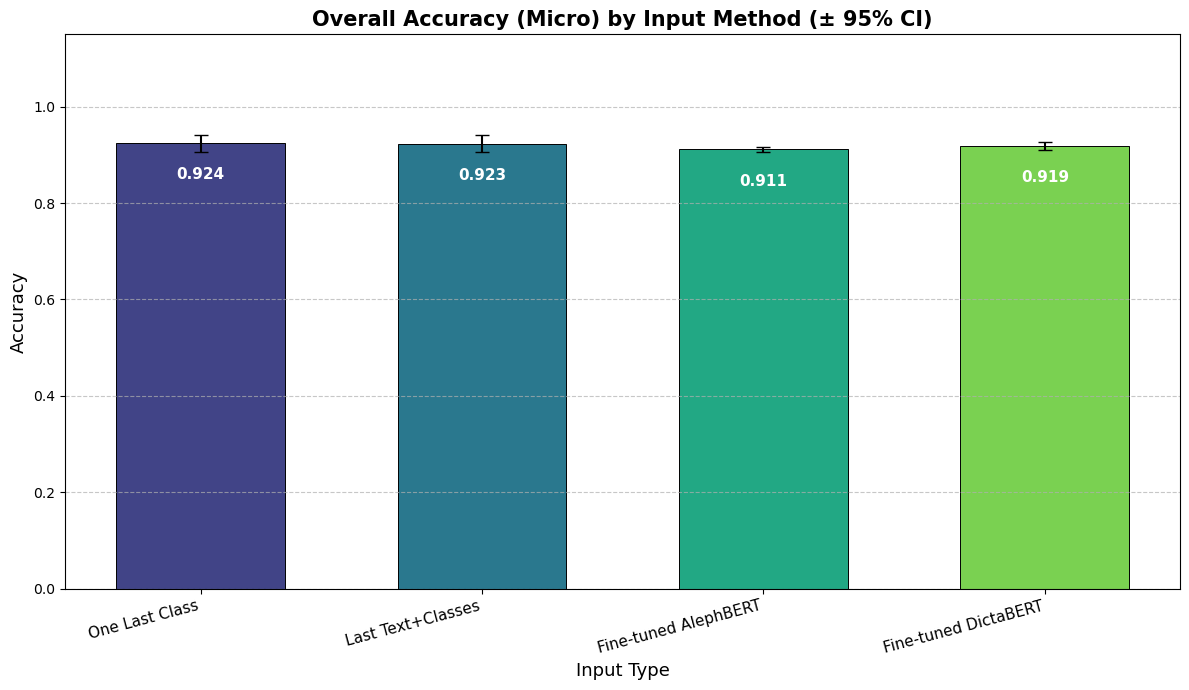

MICRO ACCURACY SUMMARY (INCLUDING FINE-TUNING)
     Type           Input_Type  Accuracy_mean  Accuracy_std  Accuracy_n  Accuracy_ci
No_titles       One Last Class       0.924104      0.083138          87     0.017470
No_titles    Last Text+Classes       0.923167      0.086699          87     0.018218
No_titles Fine-tuned AlephBERT       0.911076      0.009617          10     0.005961
No_titles Fine-tuned DictaBERT       0.918877      0.013356          10     0.008278


In [7]:
# Micro Comparison - Overall Accuracy by Input Method (INCLUDING FINE-TUNING)

accuracy_data = []

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

# Load fine-tuning results
fine_tuning_results = pd.read_csv(
    r'C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\fine_tuning\test_predictions.csv'
)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['one_last_class', 'last_text_and_classes']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    # Get file info to calculate per-file accuracy for CI
    path = os.path.join(RESULTS_PATH, TYPE, "one_last_class")
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    col_to_folder = {
        'one_last_class': 'one_last_class',
        'last_text_and_classes': 'last_text_and_classes'
    }
    col_to_input_name = {
        'one_last_class': 'One Last Class',
        'last_text_and_classes': 'Last Text+Classes'
    }
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Calculate OVERALL accuracy
        overall_acc = accuracy_score(y_true, y_pred)
        
        # Calculate per-file accuracies for error bars
        file_accuracies = []
        start_idx = 0
        for file in files:
            case = col_to_folder[col]
            file_path = os.path.join(RESULTS_PATH, TYPE, case, file)
            if os.path.exists(file_path):
                file_df = pd.read_csv(file_path)
                file_len = len(file_df)
                if file_len > 0:
                    file_y_true = y_true.iloc[start_idx:start_idx + file_len]
                    file_y_pred = y_pred.iloc[start_idx:start_idx + file_len]
                    if len(file_y_true) > 0:
                        file_acc = accuracy_score(file_y_true, file_y_pred)
                        file_accuracies.append(file_acc)
                start_idx += file_len
        
        # Calculate 95% CI
        n = len(file_accuracies)
        acc_std = np.std(file_accuracies) if n > 1 else 0
        acc_ci = Z_95 * acc_std / np.sqrt(n) if n > 0 else 0
        
        input_name = col_to_input_name[col]
        
        accuracy_data.append({
            'Type': TYPE.capitalize(),
            'Input_Type': input_name,
            'Accuracy_mean': overall_acc,
            'Accuracy_std': acc_std,
            'Accuracy_n': n,
            'Accuracy_ci': acc_ci
        })

# ===== Add fine-tuning accuracy with bootstrapping for CI =====
ft_df = fine_tuning_results.dropna(subset=['label']).copy()
ft_df['label'] = ft_df['label'].astype(str)

model_cols = ['alephbert_prediction', 'dicta_prediction']
model_name_map = {
    'alephbert_prediction': 'Fine-tuned AlephBERT',
    'dicta_prediction': 'Fine-tuned DictaBERT'
}

N_BOOTSTRAPS = 10

for col in model_cols:
    y_true = ft_df['label'].astype(str)
    y_pred = ft_df[col].astype(str)
    
    # Overall accuracy
    overall_acc = accuracy_score(y_true, y_pred)
    
    # Bootstrap for CI calculation
    bootstrap_accs = []
    for b in range(N_BOOTSTRAPS):
        sample_idx = np.random.choice(len(ft_df), size=len(ft_df), replace=True)
        sample_true = y_true.iloc[sample_idx]
        sample_pred = y_pred.iloc[sample_idx]
        bootstrap_acc = accuracy_score(sample_true, sample_pred)
        bootstrap_accs.append(bootstrap_acc)
    
    acc_std = np.std(bootstrap_accs)
    acc_ci = Z_95 * acc_std / np.sqrt(N_BOOTSTRAPS)
    
    accuracy_data.append({
        'Type': 'No_titles',
        'Input_Type': model_name_map[col],
        'Accuracy_mean': overall_acc,
        'Accuracy_std': acc_std,
        'Accuracy_n': N_BOOTSTRAPS,
        'Accuracy_ci': acc_ci
    })
# =======================================

accuracy_df = pd.DataFrame(accuracy_data)

# =====================
# Single plot: Input Types on X-axis, with 95% CI error bars (NOW WITH FINE-TUNING)
# =====================
input_order = ['One Last Class', 'Last Text+Classes', 'Fine-tuned AlephBERT', 'Fine-tuned DictaBERT']

plt.figure(figsize=(12, 7))

x = np.arange(len(input_order))
width = 0.6
colors = sns.color_palette('viridis', len(input_order))  # Bold colors

means = []
cis = []
for input_type in input_order:
    row = accuracy_df[accuracy_df['Input_Type'] == input_type]
    mean_val = row['Accuracy_mean'].values[0] if len(row) > 0 else 0
    ci_val = row['Accuracy_ci'].values[0] if len(row) > 0 else 0
    means.append(mean_val)
    # Clip CI so error bars don't exceed [0, 1]
    cis.append(clip_ci(mean_val, ci_val))

bars = plt.bar(x, means, width, color=colors, yerr=cis, capsize=5, 
               error_kw={'linewidth': 1.5}, edgecolor='black', linewidth=0.7)

# Add value labels
for j, (bar, mean_val, ci_val) in enumerate(zip(bars, means, cis)):
    if mean_val > 0.15:
        plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val - 0.05),
                    ha='center', va='top', fontsize=11, fontweight='bold', color='white')
    else:
        plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val + ci_val + 0.02),
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.xlabel('Input Type', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Overall Accuracy (Micro) by Input Method (± 95% CI)', fontsize=15, fontweight='bold')
plt.xticks(x, input_order, fontsize=11, rotation=15, ha='right')
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print summary
print("=" * 80)
print("MICRO ACCURACY SUMMARY (INCLUDING FINE-TUNING)")
print("=" * 80)
print(accuracy_df.to_string(index=False))

## Save csv of results

In [ ]:
# Save csv of results - Statistics Summary

all_stats = []

col_to_input_name = {
    'one_last_class': 'One Last Class',
    'last_text_and_classes': 'Last Text+Classes'
    }

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['one_last_class', 'last_text_and_classes']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Overall metrics
        acc = accuracy_score(y_true, y_pred)
        macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        input_name = col_to_input_name[col]
        
        # Add overall row
        all_stats.append({
            'Dataset': TYPE.capitalize(),
            'Input_Type': input_name,
            'Label': 'OVERALL',
            'Accuracy': acc,
            'Precision': macro_precision,
            'Recall': macro_recall,
            'F1-Score': macro_f1,
            'Micro-F1': micro_f1,
            'Weighted-F1': weighted_f1,
            'Support': len(y_true)
        })
        
        # Per-label metrics
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            support = (y_true == label).sum()
            
            all_stats.append({
                'Dataset': TYPE.capitalize(),
                'Input_Type': input_name,
                'Label': label,
                'Accuracy': None,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1,
                'Micro-F1': None,
                'Weighted-F1': None,
                'Support': support
            })

# Create DataFrame
stats_df = pd.DataFrame(all_stats)

# Reorder columns
stats_df = stats_df[['Dataset', 'Input_Type', 'Label', 'Accuracy', 'Precision', 'Recall', 
                     'F1-Score', 'Micro-F1', 'Weighted-F1', 'Support']]

# Save to CSV
output_path = os.path.join(RESULTS_PATH,'no_titles', 'all_statistics_summary.csv')
stats_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Statistics saved to: {output_path}")
print(f"Total rows: {len(stats_df)}")

# Display the table
print("\n" + "=" * 100)
print("OVERALL STATISTICS (per Dataset and Input Type)")
print("=" * 100)
overall_stats = stats_df[stats_df['Label'] == 'OVERALL'][['Dataset', 'Input_Type', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Support']]
print(overall_stats.to_string(index=False))

# Also create a summary pivot table
input_order = ['One Last Class', 'Last Text+Classes']

print("\n" + "=" * 100)
print("ACCURACY SUMMARY TABLE")
print("=" * 100)
accuracy_pivot = stats_df[stats_df['Label'] == 'OVERALL'].pivot(index='Dataset', columns='Input_Type', values='Accuracy')
accuracy_pivot = accuracy_pivot.reindex(columns=input_order)
print(accuracy_pivot.round(4))

print("\n" + "=" * 100)
print("F1-SCORE SUMMARY TABLE")
print("=" * 100)
f1_pivot = stats_df[stats_df['Label'] == 'OVERALL'].pivot(index='Dataset', columns='Input_Type', values='F1-Score')
f1_pivot = f1_pivot.reindex(columns=input_order)
print(f1_pivot.round(4))

# Show full dataframe
stats_df

Statistics saved to: ..\results\no_titles\all_statistics_summary.csv
Total rows: 14

OVERALL STATISTICS (per Dataset and Input Type)
  Dataset        Input_Type  Accuracy  Precision   Recall  F1-Score  Support
No_titles    One Last Class  0.871795    0.85317 0.823103  0.820400      936
No_titles Last Text+Classes  0.929487    0.86078 0.906760  0.864379      936

ACCURACY SUMMARY TABLE
Input_Type  One Last Class  Last Text+Classes
Dataset                                      
No_titles           0.8718             0.9295

F1-SCORE SUMMARY TABLE
Input_Type  One Last Class  Last Text+Classes
Dataset                                      
No_titles           0.8204             0.8644


,Dataset,Input_Type,Label,Accuracy,Precision,Recall,F1-Score,Micro-F1,Weighted-F1,Support
0,No_titles,One Last Class,OVERALL,0.871795,0.853170,0.823103,0.820400,0.871795,0.866476,936
1,No_titles,One Last Class,דיון והכרעה,NaN,0.848382,0.986139,0.912088,NaN,NaN,505
2,No_titles,One Last Class,טיעוני הצדדים,NaN,0.952000,0.610256,0.743750,NaN,NaN,195
3,No_titles,One Last Class,מידע אחר,NaN,0.921053,0.921053,0.921053,NaN,NaN,38
4,No_titles,One Last Class,עובדות המקרה,NaN,0.936937,0.896552,0.916300,NaN,NaN,116
5,No_titles,One Last Class,ראיות לעונש,NaN,0.481481,0.812500,0.604651,NaN,NaN,16
6,No_titles,One Last Class,תסקיר שירות מבחן,NaN,0.979167,0.712121,0.824561,NaN,NaN,66
7,No_titles,Last Text+Classes,OVERALL,0.929487,0.860780,0.906760,0.864379,0.929487,0.932048,936
8,No_titles,Last Text+Classes,דיון והכרעה,NaN,0.945386,0.994059,0.969112,NaN,NaN,505
9,No_titles,Last Text+Classes,טיעוני הצדדים,NaN,0.963415,0.810256,0.880223,NaN,NaN,195


In [29]:
# Classification Reports

from sklearn.metrics import classification_report

# =====================
# Classification Reports
# =====================
print("=" * 100)
print("CLASSIFICATION REPORTS")
print("=" * 100)

prediction_columns = ['one_last_class', 'last_text_and_classes']
col_to_input_name = {
    'one_last_class': 'One Last Class',
    'last_text_and_classes': 'Last Text+Classes'
}

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    print(f"\n{'='*50}")
    print(f"DATASET: {TYPE.upper()}")
    print(f"{'='*50}")
    
    for col in prediction_columns:
        input_name = col_to_input_name[col]
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        print(f"\n--- Input Type: {input_name} ---")
        print(classification_report(y_true, y_pred, labels=unique_labels, zero_division=0))

# =====================
# Save Classification Reports to CSV
# =====================
all_reports = []

for TYPE in TYPES:
    df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    df = df.dropna(subset=['label'])
    df[prediction_columns] = df[prediction_columns].fillna('MISSING')
    df['label'] = df['label'].astype(str)
    for col in prediction_columns:
        df[col] = df[col].astype(str)
    labels = sorted(df['label'].unique())
    
    for col in prediction_columns:
        input_name = col_to_input_name[col]
        y_true = df['label']
        y_pred = df[col]
        
        report_dict = classification_report(y_true, y_pred, labels=labels, 
                                            output_dict=True, zero_division=0)
        
        for label, metrics in report_dict.items():
            if isinstance(metrics, dict):
                all_reports.append({
                    'Dataset': TYPE.capitalize(),
                    'Input_Type': input_name,
                    'Label': label,
                    'Precision': metrics.get('precision', None),
                    'Recall': metrics.get('recall', None),
                    'F1-Score': metrics.get('f1-score', None),
                    'Support': metrics.get('support', None)
                })

reports_df = pd.DataFrame(all_reports)
reports_path = os.path.join(RESULTS_PATH,'no_titles', 'classification_reports.csv')
reports_df.to_csv(reports_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Classification reports saved to: {reports_path}")

CLASSIFICATION REPORTS

DATASET: NO_TITLES

--- Input Type: One Last Class ---
                  precision    recall  f1-score   support

     דיון והכרעה       0.85      0.99      0.91       505
   טיעוני הצדדים       0.95      0.61      0.74       195
        מידע אחר       0.92      0.92      0.92        38
    עובדות המקרה       0.94      0.90      0.92       116
     ראיות לעונש       0.48      0.81      0.60        16
תסקיר שירות מבחן       0.98      0.71      0.82        66

        accuracy                           0.87       936
       macro avg       0.85      0.82      0.82       936
    weighted avg       0.89      0.87      0.87       936


--- Input Type: Last Text+Classes ---
                  precision    recall  f1-score   support

     דיון והכרעה       0.95      0.99      0.97       505
   טיעוני הצדדים       0.96      0.81      0.88       195
        מידע אחר       0.92      0.92      0.92        38
    עובדות המקרה       0.96      0.85      0.90       116
     ראי